#  Seminar. Uncertainty in Deep Learning
1. Uncerainty estimation in classification.
2. Bayesian Monte Carlo dropout
3. Active learning

## Uncertainty in classification

The natural starting point for discussing bayesian approaches to classification is the joint probability $p(\mathbf{x}, y)$, where $y$ denotes the class label of features $\mathbf{x}$.  
Let $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$ be set of iid samples $(\mathbf{x}_i, y_i)\sim p(\mathbf{x}, y)$.

We could use standard discriminative model to predict label given features:
$$
y\sim p(y|\mathbf{x}, \boldsymbol{\theta})
$$
$$
\boldsymbol{\theta}^* = \text{argmax}_{\boldsymbol{\theta}}p(\mathcal{D}|\boldsymbol{\theta}) =  \text{argmax}_{\boldsymbol{\theta}}\prod_{i=1}^Np(y|\mathbf{x}, \boldsymbol{\theta})
$$
this way we get a MLE estimate of model parameters. Above we assumed that $\mathbf{x}$ is unifomly distributed on some support.

Following bayesian modeling, we want to insert some domaine knowledge and put prior on model parameters:
$$
\boldsymbol{\theta} \sim p(\boldsymbol{\theta})
$$

In order to obtain predictive model, one should marginalize $\boldsymbol{\theta}$ using posterior distribution $p(\boldsymbol{\theta}|\mathcal{D})$:
$$
p(y|\mathbf{x}, \mathcal{D}) = \int_{\boldsymbol{\theta}}p(y|\mathbf{x}, \boldsymbol{\theta})p(\boldsymbol{\theta}|\mathcal{D})d\boldsymbol{\theta}
$$

$$
p(\boldsymbol{\theta}|\mathcal{D}) = \frac{p(\mathcal{D}|\boldsymbol{\theta})p(\boldsymbol{\theta})}{p(\mathcal{D})}, \quad \text{where } p(\mathcal{D})=\int_{\boldsymbol{\theta}}p(\mathcal{D}|\boldsymbol{\theta})p(\boldsymbol{\theta})d\boldsymbol{\theta}
$$

The measure of the tolal uncertainty is the entropy of predictive disribution $\Eta[y]$, $y\sim p(y|\mathbf{x}, \mathcal{D})$



It is hard to compute porterior distribution $p(\boldsymbol{\theta}|\mathcal{D})$, due to difficulty of evidence computatation $p(\mathcal{D})$.

### Variational inference

We could approximate $p(\boldsymbol{\theta}|\mathcal{D})$ with some distribution $q(\boldsymbol{\theta})$. Then
$$
p(y|\mathbf{x}, \mathcal{D})\approx \int_{\boldsymbol{\theta}}p(y|\mathbf{x}, \boldsymbol{\theta})q(\boldsymbol{\theta})d\boldsymbol{\theta}\approx \frac{1}{M}\sum_{l=1}^M p(y|\mathbf{x}, \boldsymbol{\theta}_l), \quad \boldsymbol{\theta}_l\sim q(\boldsymbol{\theta})
$$

It can be show (see [1]) that neural network trained with dropout approximated posterior $p(\boldsymbol{\theta}|\mathcal{D})$. To get samples from $q(\boldsymbol{\theta})$ we can perform inference with active dropout.

[1] Yarin Gal, Zoubin Ghahramani Proceedings of The 33rd International Conference on Machine Learning, PMLR 48:1050-1059, 2016.
### Uncertainty decomposition

One can distinguish two types of uncertainty: aleatoric and epistemic.

Aleatoric uncertainty is related to inherent ambiguity of the data distribution $p(\mathbf{x}, y)$.

Epistemic uncertainty shows uncertainty in model' paremeters.

Mutial Information (MI) between random variables $y$ and $\boldsymbol{\theta}$ at point $\mathbf{x}$:

$$
\underbrace{MI(y, \boldsymbol{\theta}| \mathcal{D},\mathbf{x})}_{\text{Epistemic uncertainty}} = \underbrace{\Eta_{y\sim p(y|\mathbf{x}, \mathcal{D})}[y]}_{\text{Total uncertainty}} - \underbrace{\mathrm{E}_{p(\boldsymbol{\theta}|\mathcal{D})}\left[\Eta_{y\sim p(y|\mathbf{x}, \boldsymbol{\theta})}[y]\right]}_{\text{Aleatoric uncertainty}}
$$


### Monte Carlo dropout

<AxesSubplot:xlabel='x', ylabel='label'>

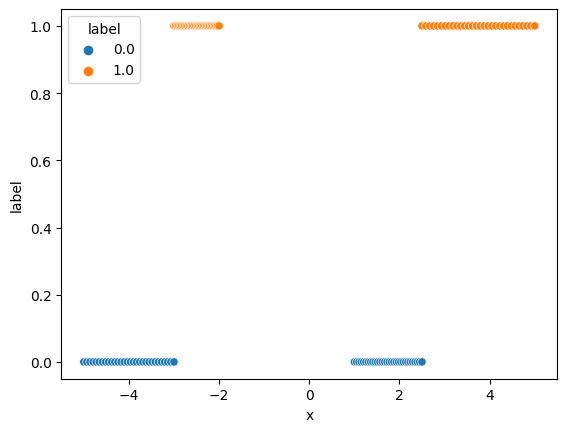

In [1]:
import torch
from torch import nn
import numpy as np
import seaborn as sns
from torch.optim.lr_scheduler import OneCycleLR
import math

# Genetate toy data
end_points = {0: [[-5, -3], [1, 2.5]], 1: [[-3, -2], [2.5, 5]]}
data = []
num_points_per_interval = 30
for class_id, intervals in end_points.items():
    for interval in intervals:
        xs = np.linspace(*interval, num_points_per_interval)
        ys = np.array([class_id] * num_points_per_interval)
        data.append(np.concatenate([xs[:, np.newaxis], ys[:, np.newaxis]], axis=1))
data = np.concatenate(data, axis=0)
data_to_vis = {"x": data[:, 0], "label": data[:, 1]}
sns.scatterplot(data=data_to_vis, x="x", y="label", hue="label")

In [2]:
device = torch.device("cuda:0")

x = torch.tensor(data[:, 0], dtype=torch.float, device=device)[:, None]

x_norm = (x - torch.min(x)) / (torch.max(x) - torch.min(x))
y = torch.tensor(data[:, 1], dtype=torch.float, device=device)[:, None]


# Use the nn package to define our model and loss function.
dropout_p = 0.2
nn.functional.dropout
model = torch.nn.Sequential(
    torch.nn.Linear(1, 10),
    nn.Sigmoid(),
    torch.nn.Linear(10, 50),
    nn.Dropout(p=dropout_p),
    nn.Sigmoid(),
    torch.nn.Linear(50, 20),
    nn.Sigmoid(),
    torch.nn.Linear(20, 1),
    nn.Flatten(),
    nn.Sigmoid(),
)
model.to(device)

loss_fn = nn.BCELoss()

learning_rate = 1e-2
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

epochs = 4000
scheduler = OneCycleLR(
    optimizer,
    max_lr=1e-1,
    steps_per_epoch=1,
    epochs=epochs,
    div_factor=1e1,
    final_div_factor=1e2,
)
for t in range(epochs):
    # Forward pass: compute predicted y by passing x to the model.
    y_pred = model(x_norm)

    # Compute and print loss.
    loss = loss_fn(y_pred, y)
    if t % 500 == 0:
        print(f"iteration {t}, loss {loss.item()}")
        # print(scheduler.get_lr())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

iteration 0, loss 0.7022371292114258
iteration 500, loss 0.06248564273118973
iteration 1000, loss 0.15033987164497375
iteration 1500, loss 0.06461503356695175
iteration 2000, loss 0.0623486302793026
iteration 2500, loss 0.07520250976085663
iteration 3000, loss 0.05259191244840622
iteration 3500, loss 0.039931006729602814


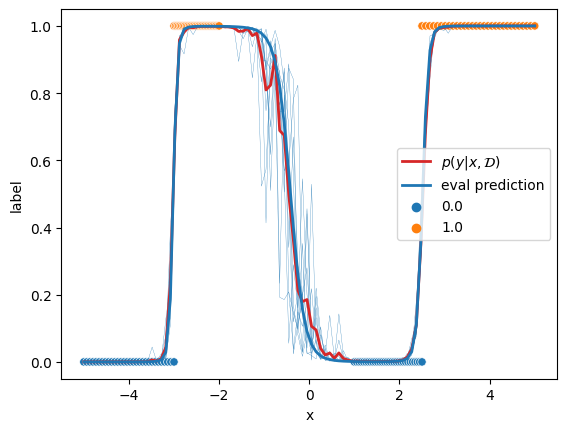

In [3]:
import matplotlib.pyplot as plt

x_test = torch.linspace(-5, 5, 100, device=device)[:, None]
x_test_norm = (x_test - torch.min(x)) / (torch.max(x) - torch.min(x))
num_sample = 10

data_to_vis = {"x": data[:, 0], "label": data[:, 1]}
sns.scatterplot(data=data_to_vis, x="x", y="label", hue="label")

p_preds = []
for _ in range(num_sample):
    model.train()  # we predict in the train mode
    p_pred = model(x_test_norm)[:, 0].detach().cpu().numpy()
    p_preds.append(p_pred[:, None])
    plt.plot(x_test[:, 0].cpu(), p_pred, color="tab:blue", linewidth=0.2)

p_preds = np.concatenate(p_preds, axis=1)
x_test = x_test[:, 0].cpu()
plt.plot(
    x_test,
    np.mean(p_preds, axis=1),
    color="tab:red",
    linewidth=2,
    label="$p(y|x, \mathcal{D})$",
)

model.eval()
p_pred_mean = model(x_test_norm)[:, 0].cpu().detach().numpy()
plt.plot(x_test, p_pred_mean, color="tab:blue", linewidth=2, label="eval prediction")
plt.legend()

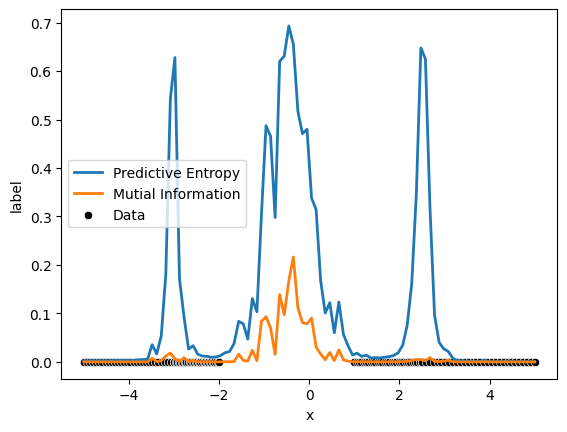

In [4]:
data_to_vis = {"x": data[:, 0], "label": [0] * len(data[:, 0])}
sns.scatterplot(data=data_to_vis, x="x", y="label", color="black", label="Data")

posterior_pred = np.mean(p_preds, axis=1)
predictive_entropy = -(
    posterior_pred * np.log(posterior_pred)
    + (1 - posterior_pred) * np.log(1 - posterior_pred)
)
mutial_information = predictive_entropy - np.mean(
    -(p_preds * np.log(p_preds) + (1 - p_preds) * np.log(1 - p_preds)), axis=1
)
plt.plot(
    x_test,
    predictive_entropy,
    color="tab:blue",
    linewidth=2,
    label="Predictive Entropy",
)
plt.plot(
    x_test,
    mutial_information,
    color="tab:orange",
    linewidth=2,
    label="Mutial Information",
)
plt.legend()

**Your task (15 min)**: Try to change model architecture (e.g. dropout probability, number weights, location of dropout) to get more diverse approximation of posterior $p(\boldsymbol{\theta}|\mathcal{D})$

**Task 1.1 (10 min):** Data Geometry and Uncertainty Types
Modify the `end_points` dictionary in the data generation cell.
- Scenario A (High Aleatoric): Make the intervals of Class 0 and Class 1 overlap significantly (e.g., `0: [[-2, 2]]`, `1: [[0, 4]]`).
- Scenario B (High Epistemic): Create a large gap between the classes where no training data exists (e.g., `0: [[-5, -3]]`, `1: [[3, 5]]`).

Run the uncertainty plotting cell. Look at the Predictive Entropy (Total) vs. Mutual Information (Epistemic) curves.  
Question: In Scenario A, which uncertainty component dominates? In Scenario B, which component dominates?  
Why does Mutual Information drop to near zero in the overlapping region despite high total uncertainty?

**Task 1.2 (10 min):** Dropout Intensity and Posterior Approximation
Change the `dropout_p` variable (currently `0.2`) to `0.1` and then to `0.5`. Retrain the model (run the training loop) and regenerate the MC Dropout prediction plots.  
Look at the spread of the blue lines (individual MC samples) in the prediction plot.  
How does increasing dropout probability affect the variance of the predictions (Epistemic uncertainty) in regions without data?  
Does too much dropout hurt the model's ability to fit the data (Aleatoric)?  
Find a balance where the model is confident in-data but uncertain out-of-data.

In [ ]:
# your code here

## 2D Classification with Uncertainty Estimation

In this section, we extend our uncertainty estimation to a 2D classification task with 3 classes. This allows us to visualize:
- Where the model is uncertain in the input space
- How uncertainty correlates with prediction errors
- How filtering uncertain samples improves accuracy

### Key Concepts:
- Aleatoric uncertainty: Due to class overlap in the data distribution (irreducible)
- Epistemic uncertainty: Due to model uncertainty in regions without training data (reducible)
- Total uncertainty: Predictive entropy = Aleatoric + Epistemic

We will create a test set with both in-distribution samples and outliers to show how total uncertainty detects both types of errors.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from matplotlib.colors import LinearSegmentedColormap

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Step 1: Generate 2D Classification Data

We create 3 Gaussian classes in 2D space:
- Class 0: Centered at (-2, 0)
- Class 1: Centered at (2, 0)
- Class 2: Centered at (0, 2)

The test set contains:
1. In-distribution samples: Same distribution as training (shows aleatoric uncertainty)
2. Out-of-distribution samples: In empty regions between classes (shows epistemic uncertainty)

In [6]:
def generate_gaussian_data(n_samples, centers, std, add_outliers=False, n_outliers=0):
    """
    Generate 2D Gaussian classification data.

    Args:
        n_samples: Number of samples per class
        centers: List of (x, y) centers for each class
        std: Standard deviation of Gaussians (controls class overlap)
        add_outliers: Whether to add outlier samples
        n_outliers: Number of outlier samples to add

    Returns:
        X: Feature array (n_total, 2)
        y: Label array (n_total,)
    """
    X_list = []
    y_list = []

    # Generate samples for each class
    for class_id, center in enumerate(centers):
        X_class = np.random.randn(n_samples, 2) * std + np.array(center)
        y_class = np.full(n_samples, class_id)
        X_list.append(X_class)
        y_list.append(y_class)

    X = np.vstack(X_list)
    y = np.hstack(y_list)

    # Add outliers in empty regions (for epistemic uncertainty)
    if add_outliers and n_outliers > 0:
        # Place outliers in regions between classes (high epistemic uncertainty)
        outlier_regions = [
            # (0, 0),      # Center (between all classes)
            (-2, -4),  # Bottom-left empty region
            # (1, -1),     # Bottom-right empty region
        ]
        outliers_per_region = n_outliers // len(outlier_regions)

        for region in outlier_regions:
            X_outlier = np.random.randn(outliers_per_region, 2) * 0.5 + np.array(region)
            y_outlier = np.random.randint(0, 3, outliers_per_region)  # Random labels
            X = np.vstack([X, X_outlier])
            y = np.hstack([y, y_outlier])

    return X, y


# Define class centers
centers = [(-2, 0), (2, 0), (0, 2)]

# Generate training data (no outliers)
X_train, y_train = generate_gaussian_data(
    n_samples=200, centers=centers, std=0.8, add_outliers=False
)

# Generate test data (with outliers for epistemic uncertainty)
X_test_ind, y_test_ind = generate_gaussian_data(
    n_samples=300, centers=centers, std=0.8, add_outliers=False
)
X_test_ood, y_test_ood = generate_gaussian_data(
    n_samples=0, centers=centers, std=0.8, add_outliers=True, n_outliers=150
)

# Combine test sets
X_test = np.vstack([X_test_ind, X_test_ood])
y_test = np.hstack([y_test_ind, y_test_ood])

# Create outlier mask for later analysis
is_outlier = np.array([False] * len(y_test_ind) + [True] * len(y_test_ood))

print(f"Training samples: {len(X_train)}")
print(f"Test samples (in-distribution): {len(y_test_ind)}")
print(f"Test samples (out-of-distribution): {len(y_test_ood)}")
print(f"Total test samples: {len(X_test)}")

Training samples: 600
Test samples (in-distribution): 900
Test samples (out-of-distribution): 150
Total test samples: 1050


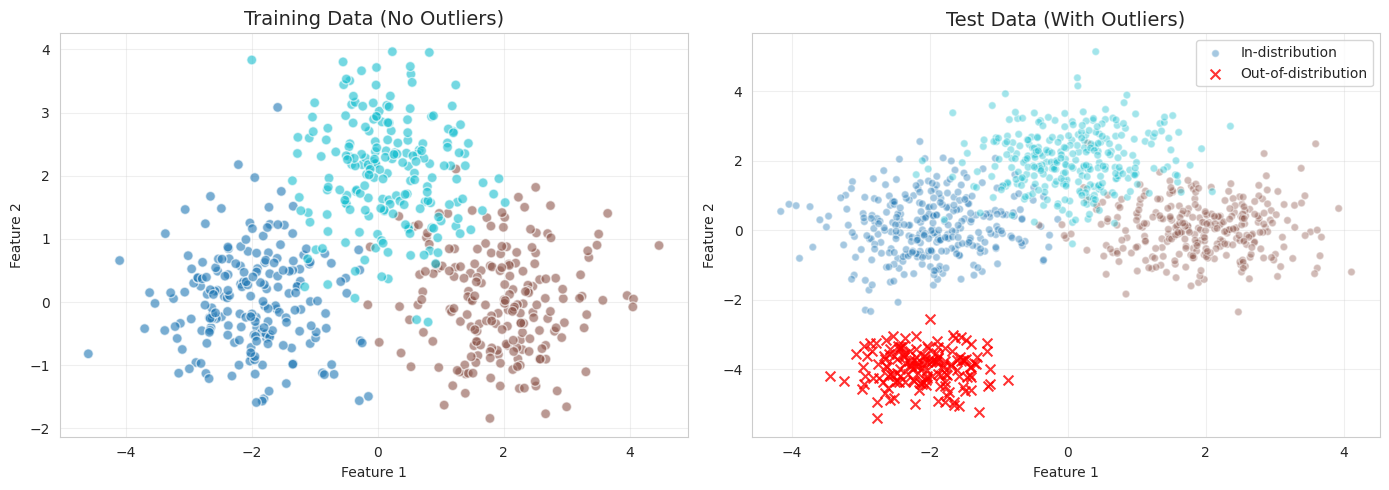

In [7]:
# Visualize training and test data distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training data
scatter1 = axes[0].scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap="tab10",
    alpha=0.6,
    edgecolors="white",
    s=50,
)
axes[0].set_title("Training Data (No Outliers)", fontsize=14)
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
# axes[0].set_xlim(-4, 4)
# axes[0].set_ylim(-3, 4)
axes[0].grid(True, alpha=0.3)

# Test data (with outliers highlighted)
scatter2 = axes[1].scatter(
    X_test[~is_outlier, 0],
    X_test[~is_outlier, 1],
    c=y_test[~is_outlier],
    cmap="tab10",
    alpha=0.4,
    edgecolors="white",
    s=30,
    label="In-distribution",
)
axes[1].scatter(
    X_test[is_outlier, 0],
    X_test[is_outlier, 1],
    c="red",
    alpha=0.8,
    edgecolors="black",
    s=50,
    label="Out-of-distribution",
    marker="x",
)
axes[1].set_title("Test Data (With Outliers)", fontsize=14)
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
# axes[1].set_xlim(-4, 4)
# axes[1].set_ylim(-3, 4)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Step 2: Define Neural Network with Dropout

We use a simple MLP with dropout layers. Dropout during inference enables Monte Carlo Dropout for uncertainty estimation.

In [8]:
class MLPWithDropout(nn.Module):
    """
    Simple MLP with dropout for uncertainty estimation via MC Dropout.
    """

    def __init__(self, input_dim=2, hidden_dims=[32, 32], output_dim=3, dropout_p=0.3):
        super(MLPWithDropout, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Sigmoid())
            layers.append(nn.Dropout(p=dropout_p))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, output_dim))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Model parameters
INPUT_DIM = 2
HIDDEN_DIMS = [32, 32]
OUTPUT_DIM = 3  # 3 classes
DROPOUT_P = 0.3  # Dropout probability
MC_SAMPLES = 100  # Number of Monte Carlo samples for uncertainty estimation

# Initialize model
model = MLPWithDropout(
    input_dim=INPUT_DIM,
    hidden_dims=HIDDEN_DIMS,
    output_dim=OUTPUT_DIM,
    dropout_p=DROPOUT_P,
)

print(f"Model architecture:")
print(model)
print(f"\nDropout probability: {DROPOUT_P}")
print(f"MC samples for uncertainty: {MC_SAMPLES}")

Model architecture:
MLPWithDropout(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Sigmoid()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): Sigmoid()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=3, bias=True)
  )
)

Dropout probability: 0.3
MC samples for uncertainty: 100


### Step 3: Train the Model

We train with CrossEntropyLoss for multi-class classification.

Training...
Epoch [100/500], Loss: 0.7824
Epoch [200/500], Loss: 0.4094
Epoch [300/500], Loss: 0.3061
Epoch [400/500], Loss: 0.2318
Epoch [500/500], Loss: 0.2377

Training completed!


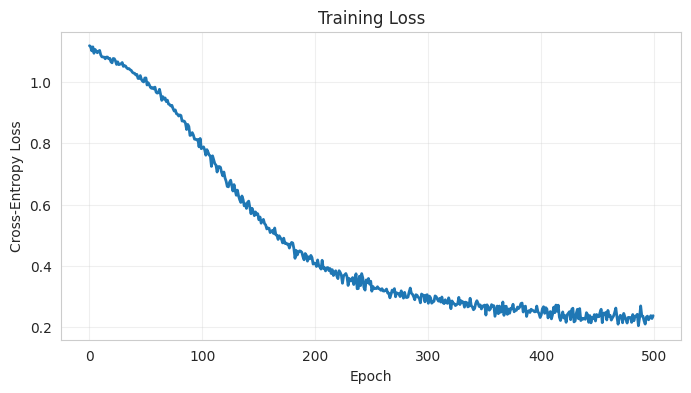

In [9]:
# Prepare data tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Training hyperparameters
LEARNING_RATE = 1e-3
EPOCHS = 500
BATCH_SIZE = 64

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training loop
train_losses = []
print("Training...")

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.4f}")

print("\nTraining completed!")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

### Step 4: Compute Uncertainty via Monte Carlo Dropout

For each test sample, we run T forward passes with dropout enabled to get a distribution of predictions.

Uncertainty Decomposition:
- Total Uncertainty (Predictive Entropy): $H[y|x,\mathcal{D}] = -\sum_c p(y=c|x,\mathcal{D}) \log p(y=c|x,\mathcal{D})$
- Aleatoric Uncertainty (Expected Entropy): $\mathbb{E}_{p(\theta|\mathcal{D})}[H[y|x,\theta]]$
- Epistemic Uncertainty (Mutual Information): $H[y|x,\mathcal{D}] - \mathbb{E}_{p(\theta|\mathcal{D})}[H[y|x,\theta]]$

Intuition:
- If all MC samples agree but predict uncertainly → Aleatoric (data is ambiguous)
- If MC samples disagree → Epistemic (model is uncertain about this region)

In [10]:
def compute_uncertainty(model, X, n_samples=100):
    """
    Compute predictive uncertainty using Monte Carlo Dropout.

    Args:
        model: Trained neural network with dropout
        X: Input features (numpy array or tensor)
        n_samples: Number of MC samples

    Returns:
        pred_mean: Mean prediction probabilities (n_points, n_classes)
        total_uncertainty: Predictive entropy (n_points,)
        aleatoric_uncertainty: Expected entropy (n_points,)
        epistemic_uncertainty: Mutual information (n_points,)
    """
    model.train()  # Keep dropout active for MC sampling

    if isinstance(X, np.ndarray):
        X = torch.FloatTensor(X)

    # Collect predictions from multiple forward passes
    all_probs = []
    for _ in range(n_samples):
        with torch.no_grad():
            logits = model(X)
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs.numpy())

    all_probs = np.stack(all_probs, axis=0)  # (n_samples, n_points, n_classes)

    # Mean predictive distribution
    pred_mean = np.mean(all_probs, axis=0)  # (n_points, n_classes)

    # Total uncertainty (predictive entropy)
    # H[y|x,D] = -sum_c p(c|x,D) log p(c|x,D)
    total_uncertainty = -np.sum(pred_mean * np.log(pred_mean + 1e-10), axis=1)

    # Aleatoric uncertainty (expected entropy over posterior)
    # E_{p(theta|D)}[H[y|x,theta]] = mean over samples of entropy for each sample
    entropy_per_sample = -np.sum(
        all_probs * np.log(all_probs + 1e-10), axis=2
    )  # (n_samples, n_points)
    aleatoric_uncertainty = np.mean(entropy_per_sample, axis=0)  # (n_points,)

    # Epistemic uncertainty (mutual information)
    # MI = Total - Aleatoric
    epistemic_uncertainty = total_uncertainty - aleatoric_uncertainty

    return pred_mean, total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty


# Compute uncertainty on test set
print("Computing uncertainty estimates...")
pred_mean, total_unc, aleatoric_unc, epistemic_unc = compute_uncertainty(
    model, X_test, n_samples=MC_SAMPLES
)

# Get predicted classes
pred_classes = np.argmax(pred_mean, axis=1)

# Compute accuracy
accuracy = accuracy_score(y_test, pred_classes)
print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Total Uncertainty - Mean: {total_unc.mean():.4f}, Std: {total_unc.std():.4f}")
print(
    f"Aleatoric Uncertainty - Mean: {aleatoric_unc.mean():.4f}, Std: {aleatoric_unc.std():.4f}"
)
print(
    f"Epistemic Uncertainty - Mean: {epistemic_unc.mean():.4f}, Std: {epistemic_unc.std():.4f}"
)

Computing uncertainty estimates...

Test Accuracy: 0.8571
Total Uncertainty - Mean: 0.3808, Std: 0.2238
Aleatoric Uncertainty - Mean: 0.2955, Std: 0.1740
Epistemic Uncertainty - Mean: 0.0853, Std: 0.0611


### Step 5: Visualize Uncertainty in Input Space

We plot the uncertainty over a grid covering the input space to see where the model is uncertain.

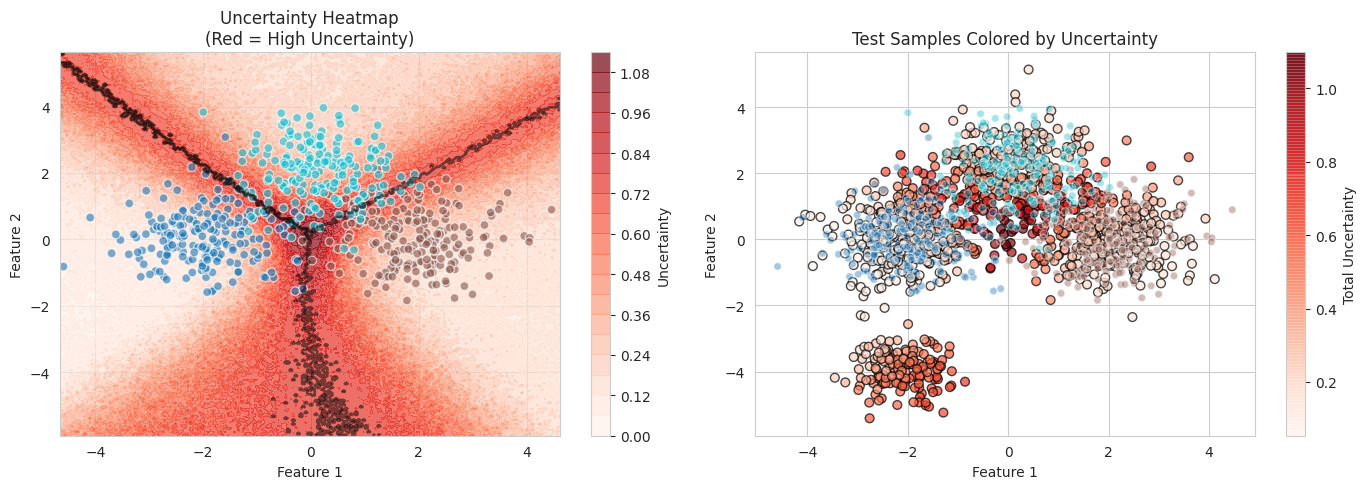

In [11]:
def plot_uncertainty_heatmap(
    X_train, y_train, X_test, total_unc, pred_classes, title="Uncertainty Heatmap"
):
    """
    Plot uncertainty heatmap over the 2D input space.
    """
    # Create grid for heatmap
    x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
    y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Compute uncertainty on grid
    _, grid_unc, _, _ = compute_uncertainty(model, grid_points, n_samples=50)
    grid_unc = grid_unc.reshape(xx.shape)

    # Compute predictions on grid for decision boundary
    grid_pred_mean, _, _, _ = compute_uncertainty(model, grid_points, n_samples=50)
    grid_pred_classes = np.argmax(grid_pred_mean, axis=1).reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Decision boundary with uncertainty overlay
    im1 = axes[0].contourf(xx, yy, grid_unc, levels=20, cmap="Reds", alpha=0.7)
    axes[0].contour(
        xx,
        yy,
        grid_pred_classes,
        levels=[0.5, 1.5, 2.5],
        colors="black",
        linewidths=2,
        alpha=0.5,
    )
    axes[0].scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=y_train,
        cmap="tab10",
        alpha=0.6,
        edgecolors="white",
        s=40,
    )
    axes[0].set_title(f"{title}\n(Red = High Uncertainty)", fontsize=12)
    axes[0].set_xlabel("Feature 1")
    axes[0].set_ylabel("Feature 2")
    plt.colorbar(im1, ax=axes[0], label="Uncertainty")

    # Plot 2: Test points colored by uncertainty
    im2 = axes[1].scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=total_unc,
        cmap="Reds",
        alpha=0.7,
        edgecolors="black",
        s=40,
    )
    axes[1].scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=y_train,
        cmap="tab10",
        alpha=0.4,
        edgecolors="white",
        s=30,
    )
    axes[1].set_title("Test Samples Colored by Uncertainty", fontsize=12)
    axes[1].set_xlabel("Feature 1")
    axes[1].set_ylabel("Feature 2")
    plt.colorbar(im2, ax=axes[1], label="Total Uncertainty")

    plt.tight_layout()
    plt.show()


# Plot uncertainty visualization
plot_uncertainty_heatmap(X_train, y_train, X_test, total_unc, pred_classes)

### Step 6: Uncertainty-Aware Test Set Filtering

Experiment: Filter out the most uncertain test samples and observe how accuracy changes.

Hypothesis: 
- Removing uncertain samples should increase accuracy
- This demonstrates that uncertainty correlates with errors
- We can use uncertainty to detect both aleatoric (overlap) and epistemic (OOD) errors

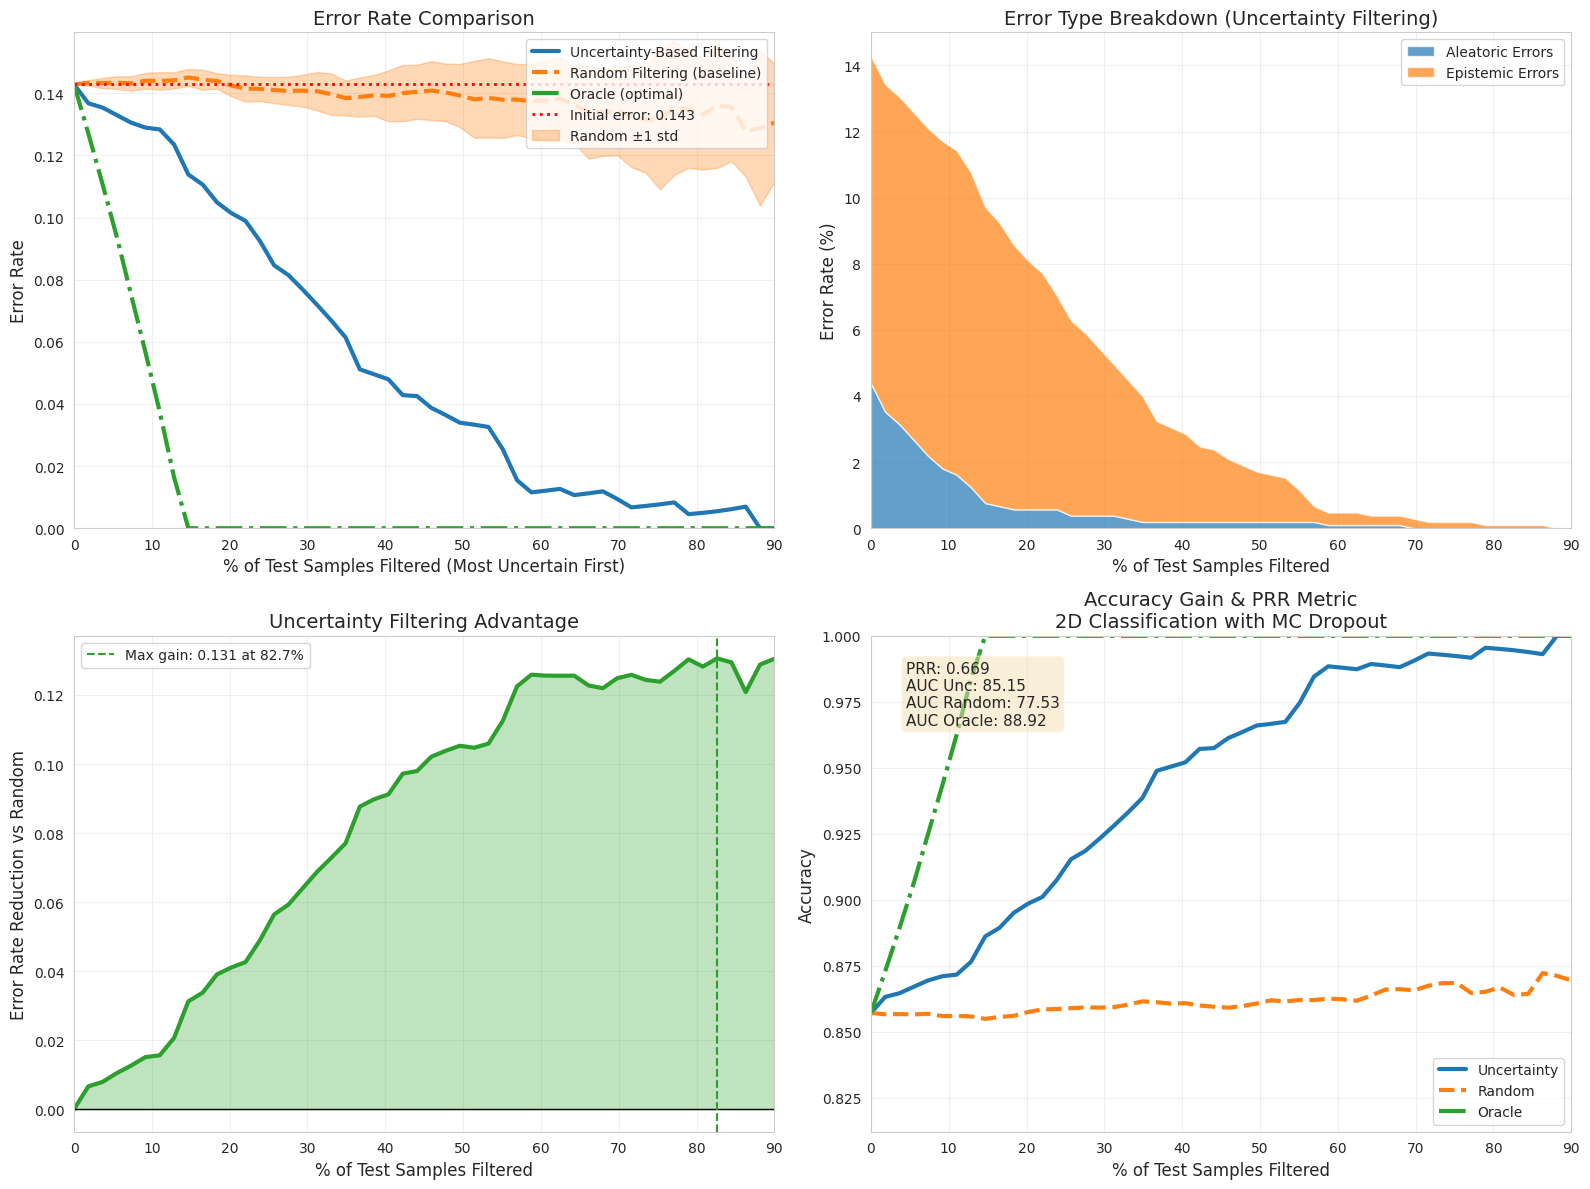


REJECTION CURVE ANALYSIS SUMMARY
Total samples: 1050
Initial error rate: 0.1429

PRR (Prediction Rejection Ratio): 0.6692
  (1.0 = Oracle, 0.0 = Random)

AUC Comparison:
  Uncertainty: 85.1505
  Random:      77.5258
  Oracle:      88.9195

Error Rate at Key Points:
  0% filtered:  Unc=0.1429, Random=0.1429, Oracle=0.1429
  50% filtered: Unc=0.0387, Random=0.1408, Oracle=0.0000

Maximum Error Rate Reduction vs Random: 0.1306
  at 82.7% filtered

Error Type Distribution:
  Aleatoric (in-distribution): 900 samples (85.7%)
  Epistemic (out-of-distribution): 150 samples (14.3%)


=== TOTAL UNCERTAINTY ===


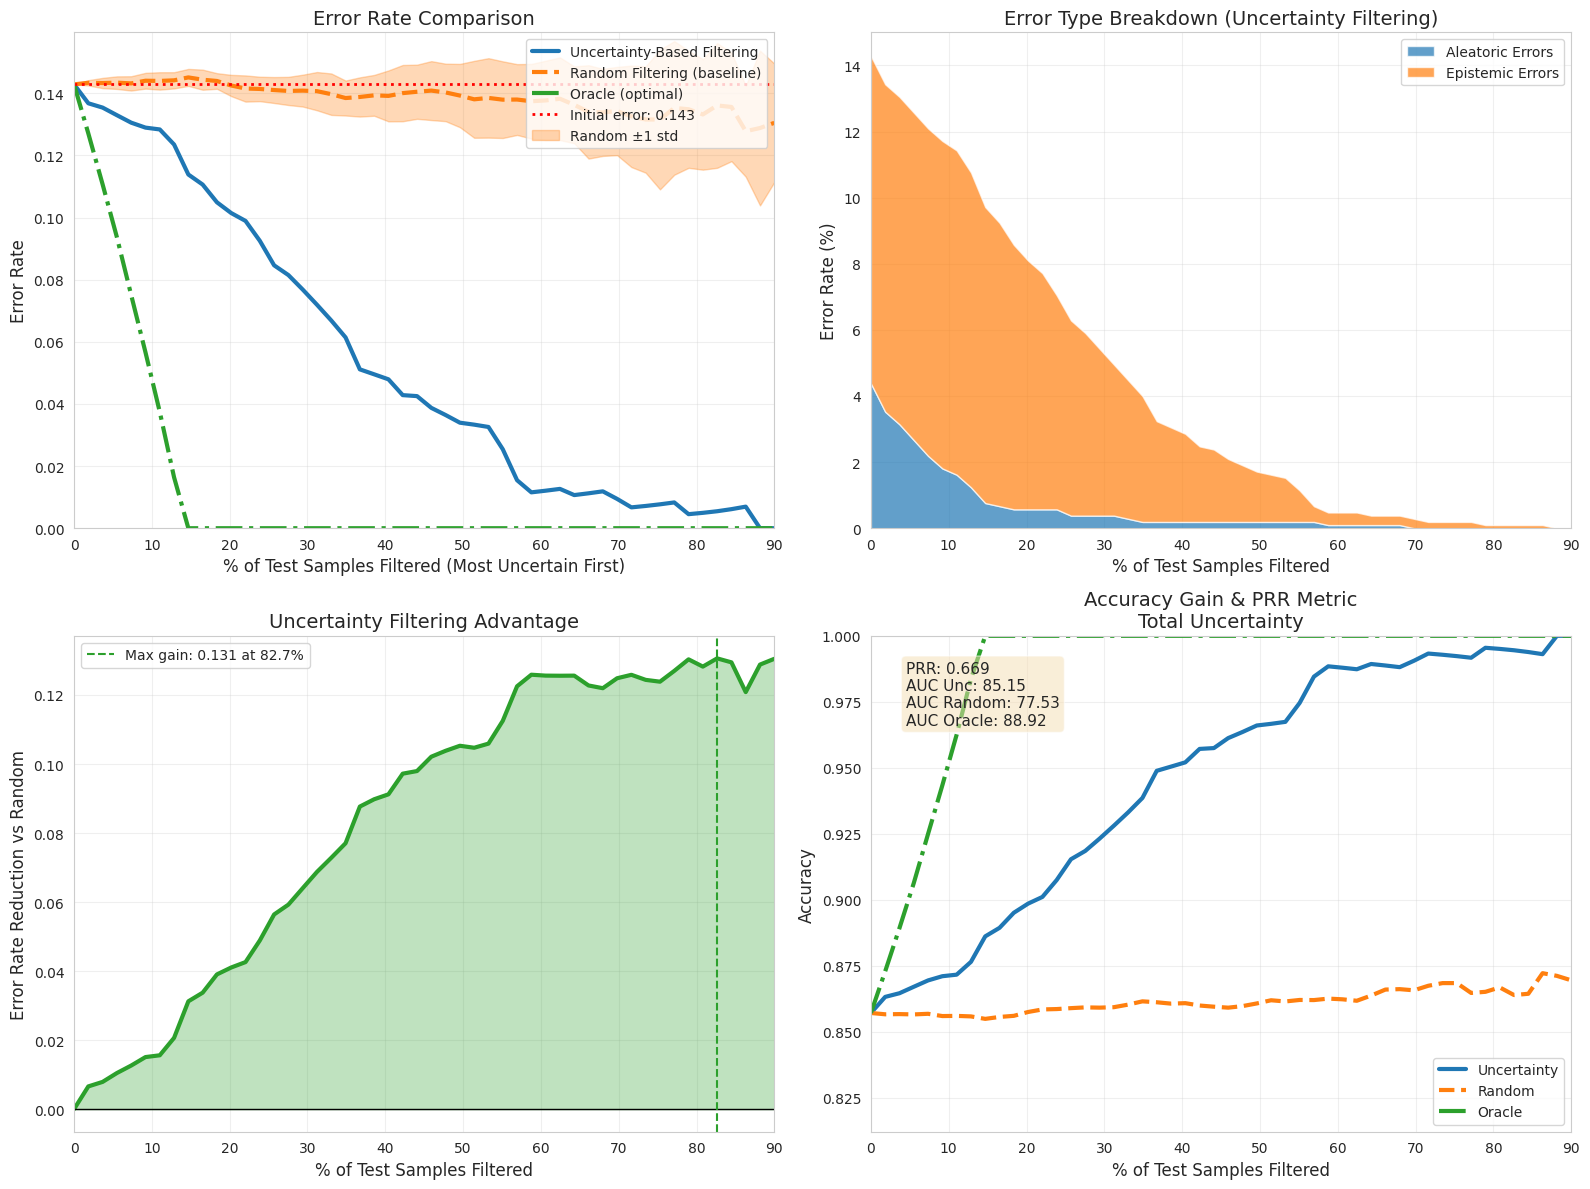


REJECTION CURVE ANALYSIS SUMMARY
Total samples: 1050
Initial error rate: 0.1429

PRR (Prediction Rejection Ratio): 0.6692
  (1.0 = Oracle, 0.0 = Random)

AUC Comparison:
  Uncertainty: 85.1505
  Random:      77.5258
  Oracle:      88.9195

Error Rate at Key Points:
  0% filtered:  Unc=0.1429, Random=0.1429, Oracle=0.1429
  50% filtered: Unc=0.0387, Random=0.1408, Oracle=0.0000

Maximum Error Rate Reduction vs Random: 0.1306
  at 82.7% filtered

Error Type Distribution:
  Aleatoric (in-distribution): 900 samples (85.7%)
  Epistemic (out-of-distribution): 150 samples (14.3%)


=== EPISTEMIC UNCERTAINTY ===


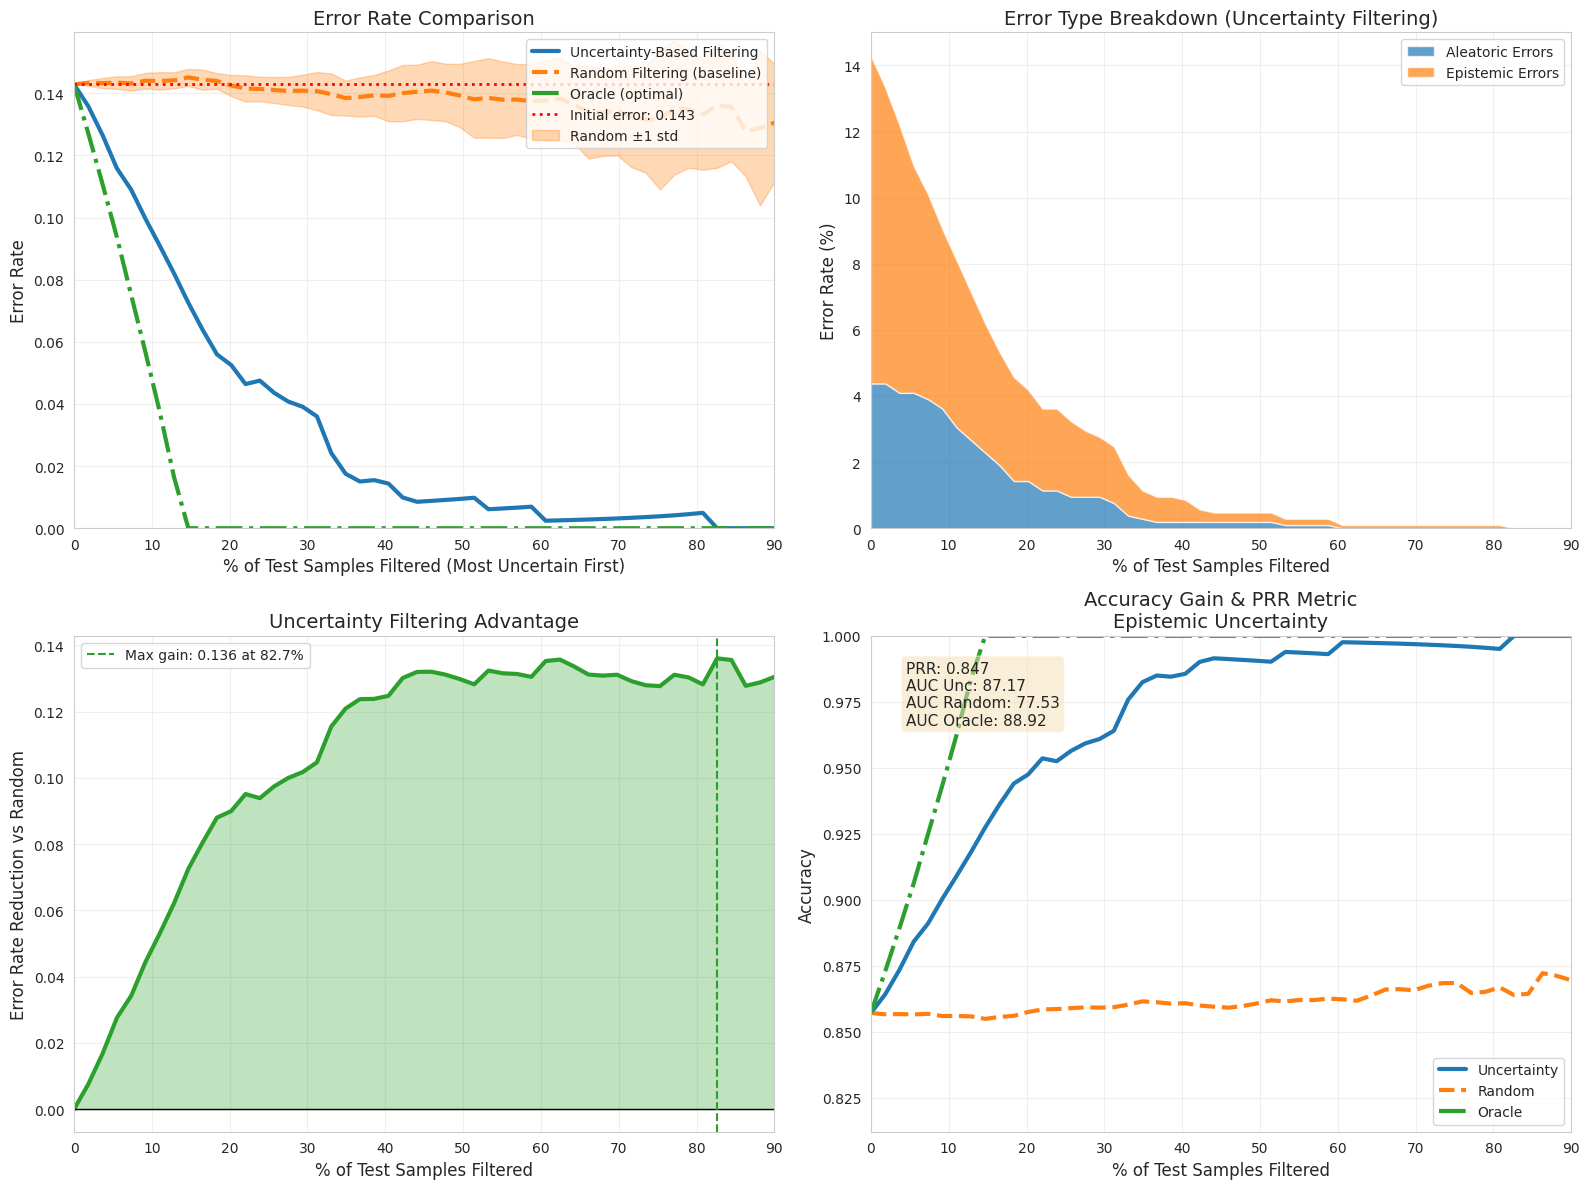


REJECTION CURVE ANALYSIS SUMMARY
Total samples: 1050
Initial error rate: 0.1429

PRR (Prediction Rejection Ratio): 0.8469
  (1.0 = Oracle, 0.0 = Random)

AUC Comparison:
  Uncertainty: 87.1748
  Random:      77.5258
  Oracle:      88.9195

Error Rate at Key Points:
  0% filtered:  Unc=0.1429, Random=0.1429, Oracle=0.1429
  50% filtered: Unc=0.0088, Random=0.1408, Oracle=0.0000

Maximum Error Rate Reduction vs Random: 0.1361
  at 82.7% filtered

Error Type Distribution:
  Aleatoric (in-distribution): 900 samples (85.7%)
  Epistemic (out-of-distribution): 150 samples (14.3%)


=== ALEATORIC UNCERTAINTY ===


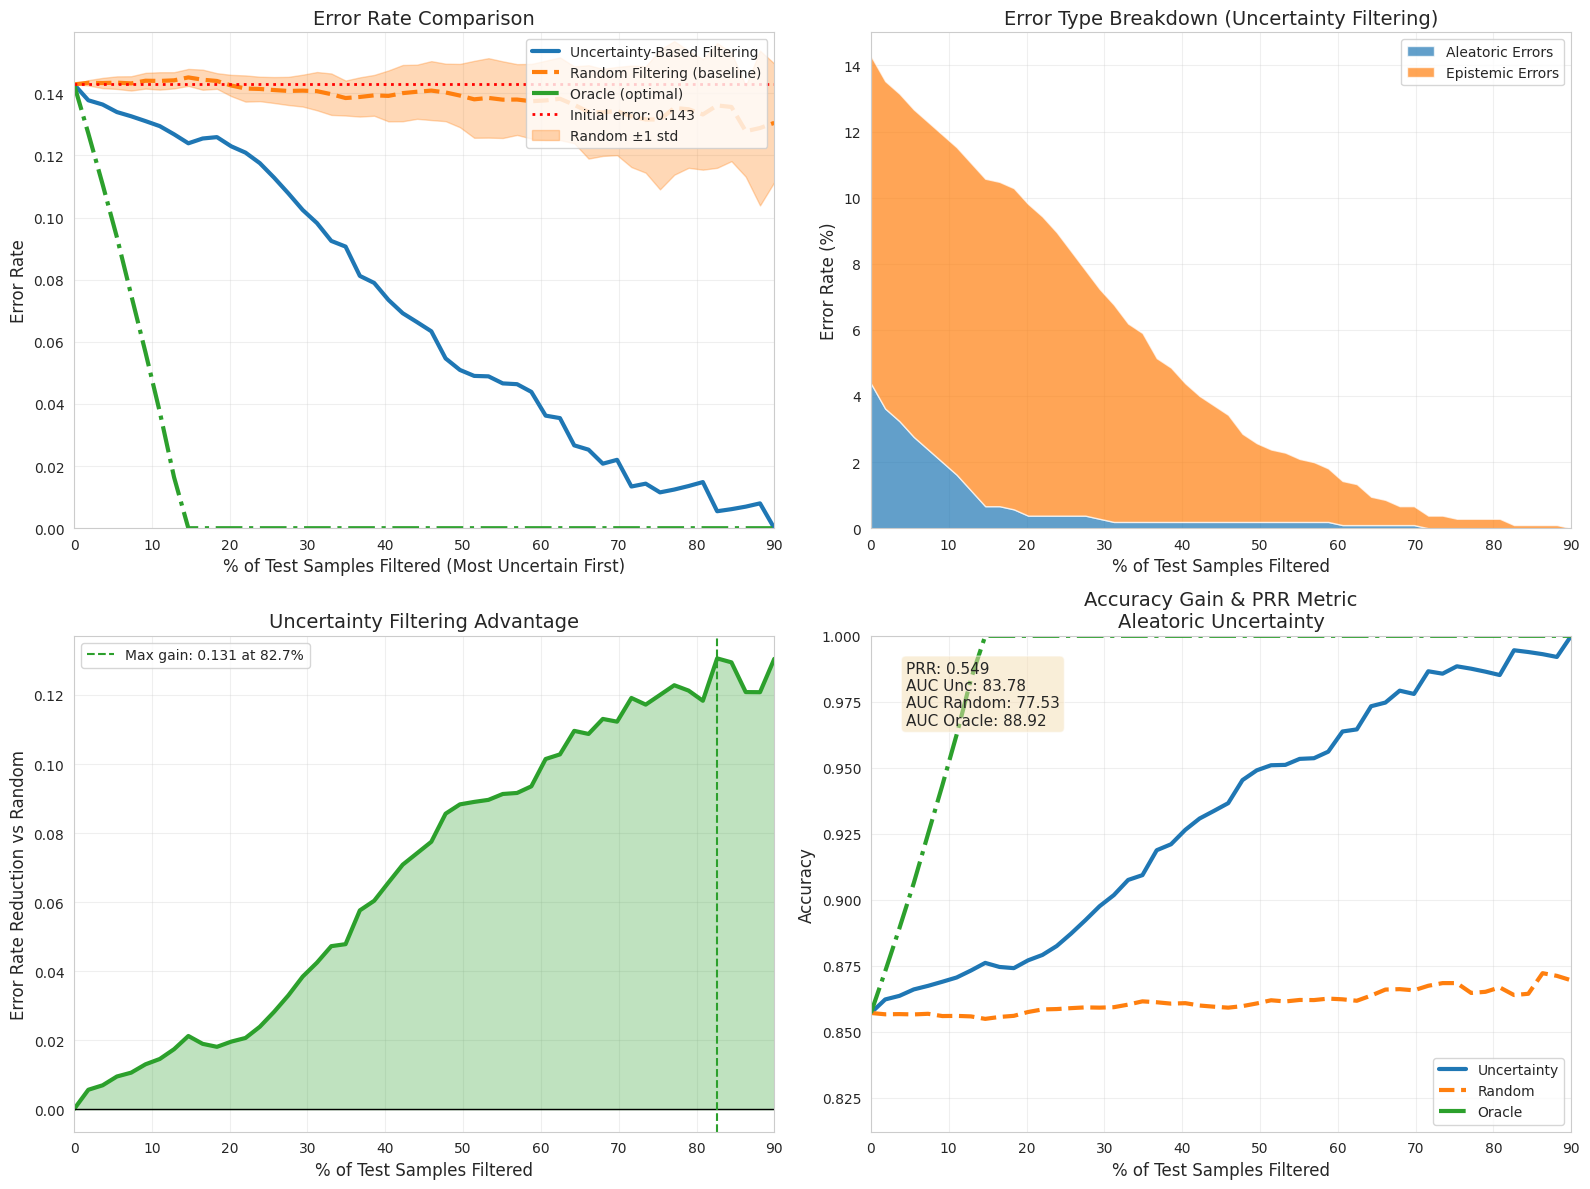


REJECTION CURVE ANALYSIS SUMMARY
Total samples: 1050
Initial error rate: 0.1429

PRR (Prediction Rejection Ratio): 0.5490
  (1.0 = Oracle, 0.0 = Random)

AUC Comparison:
  Uncertainty: 83.7808
  Random:      77.5258
  Oracle:      88.9195

Error Rate at Key Points:
  0% filtered:  Unc=0.1429, Random=0.1429, Oracle=0.1429
  50% filtered: Unc=0.0634, Random=0.1408, Oracle=0.0000

Maximum Error Rate Reduction vs Random: 0.1306
  at 82.7% filtered

Error Type Distribution:
  Aleatoric (in-distribution): 900 samples (85.7%)
  Epistemic (out-of-distribution): 150 samples (14.3%)


=== PRR COMPARISON ===
Total Uncertainty PRR:      0.6692
Epistemic Uncertainty PRR:  0.8469
Aleatoric Uncertainty PRR:  0.5490


In [ ]:
def uncertainty_filtering_experiment(
    y_true, y_pred, uncertainty, is_outlier=None, n_random_runs=10
):
    """
    Perform uncertainty-aware filtering and compute error rate at each threshold.
    Includes random filtering baseline and oracle curve for PRR calculation.

    Args:
        y_true: True labels
        y_pred: Predicted labels
        uncertainty: Uncertainty scores (higher = more uncertain)
        is_outlier: Optional mask for outlier samples (True = OOD/epistemic)
        n_random_runs: Number of random filtering runs for averaging

    Returns:
        percent_filtered: % of samples filtered (0 to 100)
        error_rates_unc: Error rate for uncertainty filtering at each threshold
        error_rates_random: Mean error rate for random filtering at each threshold
        error_rates_random_std: Std of error rate for random filtering
        error_rates_oracle: Optimal error rate (oracle removes errors first)
        error_breakdown: Breakdown of error types at each threshold
        prr: Prediction Rejection Ratio
    """
    n_samples = len(y_true)
    percent_filtered = np.linspace(0, 90, 50)  # 0% to 90% filtered
    error_rates_unc = []
    error_rates_random_all = np.zeros((n_random_runs, len(percent_filtered)))
    error_rates_oracle = []
    error_breakdown = {
        "total_errors": [],
        "aleatoric_errors": [],
        "epistemic_errors": [],
        "total_errors_random": [],
        "total_errors_oracle": [],
    }

    # Identify errors
    errors = y_true != y_pred
    n_total_errors = np.sum(errors)

    # ============ UNCERTAINTY-BASED FILTERING ============
    # Sort by uncertainty (ascending - most certain first, keep these)
    sorted_idx = np.argsort(uncertainty)

    for i, pct in enumerate(percent_filtered):
        n_filtered = int(pct / 100 * n_samples)
        n_keep = n_samples - n_filtered
        keep_idx = sorted_idx[:n_keep]  # Keep the most certain samples

        if n_keep == 0:
            error_rates_unc.append(1.0)
            error_breakdown["total_errors"].append(n_samples)
            error_breakdown["aleatoric_errors"].append(
                n_samples if is_outlier is None else np.sum(~is_outlier)
            )
            error_breakdown["epistemic_errors"].append(
                0 if is_outlier is None else np.sum(is_outlier)
            )
            continue

        # Compute error rate on kept samples
        errors_kept = errors[keep_idx]
        error_rate = np.mean(errors_kept) if n_keep > 0 else 1.0
        error_rates_unc.append(error_rate)

        # Error breakdown
        total_errors_kept = np.sum(errors_kept)

        if is_outlier is not None:
            aleatoric_errors_kept = np.sum(errors_kept & (~is_outlier[keep_idx]))
            epistemic_errors_kept = np.sum(errors_kept & is_outlier[keep_idx])
        else:
            aleatoric_errors_kept = total_errors_kept
            epistemic_errors_kept = 0

        error_breakdown["total_errors"].append(total_errors_kept)
        error_breakdown["aleatoric_errors"].append(aleatoric_errors_kept)
        error_breakdown["epistemic_errors"].append(epistemic_errors_kept)

    # ============ RANDOM FILTERING BASELINE ============
    np.random.seed(42)  # For reproducibility
    for run in range(n_random_runs):
        random_idx = np.random.permutation(n_samples)
        for i, pct in enumerate(percent_filtered):
            n_filtered = int(pct / 100 * n_samples)
            n_keep = n_samples - n_filtered
            keep_idx = random_idx[:n_keep]

            if n_keep == 0:
                error_rates_random_all[run, i] = 1.0
                continue

            errors_kept = errors[keep_idx]
            error_rates_random_all[run, i] = np.mean(errors_kept)

    error_rates_random = np.mean(error_rates_random_all, axis=0)
    error_rates_random_std = np.std(error_rates_random_all, axis=0)

    # ============ ORACLE FILTERING (Optimal) ============
    # Oracle removes errors first (perfect uncertainty estimation)
    error_idx = np.where(errors)[0]
    correct_idx = np.where(~errors)[0]
    oracle_sorted_idx = np.concatenate(
        [error_idx, correct_idx]
    )  # Errors first to filter

    for i, pct in enumerate(percent_filtered):
        n_filtered = int(pct / 100 * n_samples)
        n_keep = n_samples - n_filtered
        keep_idx = oracle_sorted_idx[n_filtered:]  # Remove errors first

        if n_keep == 0:
            error_rates_oracle.append(1.0)
            error_breakdown["total_errors_oracle"].append(n_samples)
            continue

        errors_kept = errors[keep_idx]
        error_rate = np.mean(errors_kept) if n_keep > 0 else 1.0
        error_rates_oracle.append(error_rate)
        error_breakdown["total_errors_oracle"].append(np.sum(errors_kept))

    # ============ CALCULATE PRR (Prediction Rejection Ratio) ============
    # PRR = (AUC_unc - AUC_random) / (AUC_oracle - AUC_random)
    # Higher PRR = better uncertainty estimation (1.0 = oracle, 0.0 = random)

    # Calculate AUC using trapezoidal rule (error rate vs % filtered)
    accuracy_unc = 1 - np.array(error_rates_unc)
    accuracy_random = 1 - error_rates_random
    accuracy_oracle = 1 - np.array(error_rates_oracle)

    auc_unc = np.trapz(accuracy_unc, percent_filtered)
    auc_random = np.trapz(accuracy_random, percent_filtered)
    auc_oracle = np.trapz(accuracy_oracle, percent_filtered)

    # PRR calculation
    if auc_oracle - auc_random > 0:
        prr = (auc_unc - auc_random) / (auc_oracle - auc_random)
    else:
        prr = 0.0

    error_breakdown["total_errors_random"] = [
        int((1 - acc) * n_samples) for acc in accuracy_random
    ]

    return (
        percent_filtered,
        error_rates_unc,
        error_rates_random,
        error_rates_random_std,
        error_rates_oracle,
        error_breakdown,
        prr,
        auc_unc,
        auc_random,
        auc_oracle,
    )


def plot_rejection_curves_comprehensive(
    y_true,
    y_pred,
    uncertainty,
    is_outlier=None,
    n_random_runs=10,
    title="Rejection Curve Analysis",
):
    """
    Plot comprehensive rejection curves with error breakdown and PRR.
    """
    # Run filtering experiment
    (
        percent_filtered,
        error_rates_unc,
        error_rates_random,
        error_rates_random_std,
        error_rates_oracle,
        error_breakdown,
        prr,
        auc_unc,
        auc_random,
        auc_oracle,
    ) = uncertainty_filtering_experiment(
        y_true, y_pred, uncertainty, is_outlier, n_random_runs
    )

    # Convert to numpy arrays for plotting
    error_rates_unc = np.array(error_rates_unc)
    error_rates_random = np.array(error_rates_random)
    error_rates_oracle = np.array(error_rates_oracle)
    aleatoric_errors = np.array(error_breakdown["aleatoric_errors"])
    epistemic_errors = np.array(error_breakdown["epistemic_errors"])
    total_errors = np.array(error_breakdown["total_errors"])

    n_samples = len(y_true)

    # Create figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # ============ PLOT 1: Error Rate vs % Filtered (Main Comparison) ============
    axes[0, 0].plot(
        percent_filtered,
        error_rates_unc,
        linewidth=3,
        color="tab:blue",
        label="Uncertainty-Based Filtering",
    )
    axes[0, 0].plot(
        percent_filtered,
        error_rates_random,
        linewidth=3,
        color="tab:orange",
        linestyle="--",
        label="Random Filtering (baseline)",
    )
    axes[0, 0].fill_between(
        percent_filtered,
        error_rates_random - error_rates_random_std,
        error_rates_random + error_rates_random_std,
        alpha=0.3,
        color="tab:orange",
        label="Random ±1 std",
    )
    axes[0, 0].plot(
        percent_filtered,
        error_rates_oracle,
        linewidth=3,
        color="tab:green",
        linestyle="-.",
        label="Oracle (optimal)",
    )

    initial_error = error_rates_unc[0]
    axes[0, 0].axhline(
        y=initial_error,
        color="red",
        linestyle=":",
        linewidth=2,
        label=f"Initial error: {initial_error:.3f}",
    )

    axes[0, 0].set_xlabel(
        "% of Test Samples Filtered (Most Uncertain First)", fontsize=12
    )
    axes[0, 0].set_ylabel("Error Rate", fontsize=12)
    axes[0, 0].set_title("Error Rate Comparison", fontsize=14)
    axes[0, 0].set_xlim(0, 90)
    axes[0, 0].set_ylim(0, max(error_rates_random) * 1.1)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend(loc="upper right")

    # ============ PLOT 2: Error Type Breakdown (Aleatoric vs Epistemic) ============
    if is_outlier is not None:
        # Calculate error rates for each type
        aleatoric_rate = (
            aleatoric_errors / n_samples * 100
        )  # Convert to percentage of total
        epistemic_rate = epistemic_errors / n_samples * 100

        axes[0, 1].stackplot(
            percent_filtered,
            aleatoric_rate,
            epistemic_rate,
            labels=["Aleatoric Errors", "Epistemic Errors"],
            colors=["tab:blue", "tab:orange"],
            alpha=0.7,
        )
        axes[0, 1].set_xlabel("% of Test Samples Filtered", fontsize=12)
        axes[0, 1].set_ylabel("Error Rate (%)", fontsize=12)
        axes[0, 1].set_title(
            "Error Type Breakdown (Uncertainty Filtering)", fontsize=14
        )
        axes[0, 1].set_xlim(0, 90)
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].legend(loc="upper right")
    else:
        axes[0, 1].text(
            0.5,
            0.5,
            "No outlier mask provided\n(Cannot separate error types)",
            ha="center",
            va="center",
            fontsize=14,
            transform=axes[0, 1].transAxes,
        )
        axes[0, 1].set_title("Error Type Breakdown", fontsize=14)
        axes[0, 1].axis("off")

    # ============ PLOT 3: Error Rate Reduction vs Random ============
    error_rate_gain = error_rates_random - error_rates_unc
    axes[1, 0].plot(percent_filtered, error_rate_gain, linewidth=3, color="tab:green")
    axes[1, 0].fill_between(
        percent_filtered, 0, error_rate_gain, alpha=0.3, color="tab:green"
    )
    axes[1, 0].axhline(y=0, color="black", linestyle="-", linewidth=1)

    max_gain_idx = np.argmax(error_rate_gain)
    axes[1, 0].axvline(
        x=percent_filtered[max_gain_idx],
        color="tab:green",
        linestyle="--",
        label=f"Max gain: {error_rate_gain[max_gain_idx]:.3f} at {percent_filtered[max_gain_idx]:.1f}%",
    )

    axes[1, 0].set_xlabel("% of Test Samples Filtered", fontsize=12)
    axes[1, 0].set_ylabel("Error Rate Reduction vs Random", fontsize=12)
    axes[1, 0].set_title("Uncertainty Filtering Advantage", fontsize=14)
    axes[1, 0].set_xlim(0, 90)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # ============ PLOT 4: Accuracy Gain & PRR ============
    accuracy_unc = 1 - error_rates_unc
    accuracy_random = 1 - error_rates_random
    accuracy_oracle = 1 - error_rates_oracle

    axes[1, 1].plot(
        percent_filtered,
        accuracy_unc,
        linewidth=3,
        color="tab:blue",
        label="Uncertainty",
    )
    axes[1, 1].plot(
        percent_filtered,
        accuracy_random,
        linewidth=3,
        color="tab:orange",
        linestyle="--",
        label="Random",
    )
    axes[1, 1].plot(
        percent_filtered,
        accuracy_oracle,
        linewidth=3,
        color="tab:green",
        linestyle="-.",
        label="Oracle",
    )

    # Add PRR annotation
    prr_text = f"PRR: {prr:.3f}\n"
    prr_text += f"AUC Unc: {auc_unc:.2f}\n"
    prr_text += f"AUC Random: {auc_random:.2f}\n"
    prr_text += f"AUC Oracle: {auc_oracle:.2f}"

    axes[1, 1].text(
        0.05,
        0.95,
        prr_text,
        transform=axes[1, 1].transAxes,
        fontsize=11,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    axes[1, 1].set_xlabel("% of Test Samples Filtered", fontsize=12)
    axes[1, 1].set_ylabel("Accuracy", fontsize=12)
    axes[1, 1].set_title(f"Accuracy Gain & PRR Metric\n{title}", fontsize=14)
    axes[1, 1].set_xlim(0, 90)
    axes[1, 1].set_ylim(min(accuracy_random) * 0.95, 1.0)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    # ============ PRINT SUMMARY STATISTICS ============
    print("\n" + "=" * 70)
    print("REJECTION CURVE ANALYSIS SUMMARY")
    print("=" * 70)
    print(f"Total samples: {n_samples}")
    print(f"Initial error rate: {error_rates_unc[0]:.4f}")
    print(f"\nPRR (Prediction Rejection Ratio): {prr:.4f}")
    print(f"  (1.0 = Oracle, 0.0 = Random)")
    print(f"\nAUC Comparison:")
    print(f"  Uncertainty: {auc_unc:.4f}")
    print(f"  Random:      {auc_random:.4f}")
    print(f"  Oracle:      {auc_oracle:.4f}")
    print(f"\nError Rate at Key Points:")
    print(
        f"  0% filtered:  Unc={error_rates_unc[0]:.4f}, Random={error_rates_random[0]:.4f}, Oracle={error_rates_oracle[0]:.4f}"
    )
    mid_idx = len(percent_filtered) // 2
    print(
        f"  50% filtered: Unc={error_rates_unc[mid_idx]:.4f}, Random={error_rates_random[mid_idx]:.4f}, Oracle={error_rates_oracle[mid_idx]:.4f}"
    )
    print(f"\nMaximum Error Rate Reduction vs Random: {max(error_rate_gain):.4f}")
    print(f"  at {percent_filtered[max_gain_idx]:.1f}% filtered")

    if is_outlier is not None:
        n_aleatoric = np.sum(~is_outlier)
        n_epistemic = np.sum(is_outlier)
        print(f"\nError Type Distribution:")
        print(
            f"  Aleatoric (in-distribution): {n_aleatoric} samples ({n_aleatoric/n_samples*100:.1f}%)"
        )
        print(
            f"  Epistemic (out-of-distribution): {n_epistemic} samples ({n_epistemic/n_samples*100:.1f}%)"
        )

    print("=" * 70)

    return {
        "percent_filtered": percent_filtered,
        "error_rates_unc": error_rates_unc,
        "error_rates_random": error_rates_random,
        "error_rates_random_std": error_rates_random_std,
        "error_rates_oracle": error_rates_oracle,
        "error_breakdown": error_breakdown,
        "prr": prr,
        "auc_unc": auc_unc,
        "auc_random": auc_random,
        "auc_oracle": auc_oracle,
    }


# Plot comprehensive rejection curves
results = plot_rejection_curves_comprehensive(
    y_test,
    pred_classes,
    total_unc,
    is_outlier=is_outlier,
    n_random_runs=10,
    title="2D Classification with MC Dropout",
)

print("\n\n=== TOTAL UNCERTAINTY ===")
results_total = plot_rejection_curves_comprehensive(
    y_test, pred_classes, total_unc, is_outlier=is_outlier, title="Total Uncertainty"
)

print("\n\n=== EPISTEMIC UNCERTAINTY ===")
results_epistemic = plot_rejection_curves_comprehensive(
    y_test,
    pred_classes,
    epistemic_unc,
    is_outlier=is_outlier,
    title="Epistemic Uncertainty",
)

print("\n\n=== ALEATORIC UNCERTAINTY ===")
results_aleatoric = plot_rejection_curves_comprehensive(
    y_test,
    pred_classes,
    aleatoric_unc,
    is_outlier=is_outlier,
    title="Aleatoric Uncertainty",
)

# Compare PRR scores
print("\n\n=== PRR COMPARISON ===")
print(f"Total Uncertainty PRR:      {results_total['prr']:.4f}")
print(f"Epistemic Uncertainty PRR:  {results_epistemic['prr']:.4f}")
print(f"Aleatoric Uncertainty PRR:  {results_aleatoric['prr']:.4f}")

**Task 2.1 (10 min):** OOD Location and Epistemic Uncertainty  
Modify the `outlier_regions` list inside the `generate_gaussian_data` function.
- Case A: Place outliers in the center `(0, 0)` (between all three classes).
- Case B: Place outliers far away from all clusters (e.g., `(-10, -10)`).

Run the `plot_uncertainty_heatmap` and the `plot_rejection_curves_comprehensive` cells.  
Does Epistemic Uncertainty (Mutual Information) detect both cases equally well?  
How does the Epistemic Uncertainty PRR change compared to the Aleatoric Uncertainty PRR when outliers are far away vs. between classes?

**Task 2.2 (10 min):** Class Ambiguity and Aleatoric Uncertainty
Increase the `std` parameter in the `generate_gaussian_data` function (e.g., from `0.8` to `1.5`) for both training and test sets.  
This creates significant overlap between the three Gaussian classes.  
Re-run the uncertainty computation and the Rejection Curve Analysis.  
How does increasing class overlap affect the Aleatoric Uncertainty mean value?  
Does filtering by Total Uncertainty become more effective than filtering by Epistemic Uncertainty in this high-ambiguity setting? Why?

**Task 2.3 (10 min):** The "Oracle" vs. Uncertainty Filtering  
Look at the Rejection Curve plots (Error Rate vs. % Filtered).  
Focus on the gap between the Uncertainty-Based Filtering (blue line) and the Oracle (green line).  
Try to reduce the `MC_SAMPLES` (currently `100`) to `10` or `5` in the `compute_uncertainty` function.  
How does reducing the number of Monte Carlo samples affect the quality of the uncertainty estimate?  
Does the blue line move closer to the orange line (Random) or stay near the green line (Oracle)?  
What does this imply about the computational cost vs. benefit of MC Dropout?


In [ ]:
# your code here

## 3. Active Learning with Uncertainty Estimation

### What is Active Learning?

Active Learning is a semi-supervised learning paradigm where the model actively selects which data points to label next from a pool of unlabeled data. Instead of randomly acquiring labels (which can be expensive or time-consuming), we use uncertainty estimation to identify the most informative samples.

### Connection to Uncertainty Estimation

The key insight is: samples where the model is most uncertain are likely the most informative for learning. By querying labels for these uncertain points, we can:
- Reduce the number of labeled samples needed
- Achieve higher accuracy with less training data
- Focus labeling effort on ambiguous or edge cases

### Acquisition Functions

We compare three query strategies:
Random (Uniform), Max Predictive Entropy, BALD (Bayesian Active Learning by Disagreement)

### Key Difference: Entropy vs. BALD

- Max Entropy selects points where the *average* prediction is uncertain (could be due to aleatoric uncertainty)
- BALD selects points where individual MC dropout samples *disagree* with each other (purely epistemic uncertainty)

BALD is theoretically preferred for active learning because:
1. Aleatoric uncertainty cannot be reduced by acquiring more labels
2. Epistemic uncertainty *can* be reduced by labeling uncertain regions

### Experimental Setup

- Dataset: MNIST (binary classification: digit 9 vs. all others)
- Model: CNN with dropout (enables MC Dropout uncertainty)
- Initial Training Set: Only 20 labeled samples (10 per class)
- Query Strategy: Select 1 sample per iteration using each acquisition function
- Evaluation: Track validation accuracy over 100 query iterations

### What to Observe

1. Learning Curves: Compare how quickly each acquisition function improves accuracy
2. BALD vs. Entropy: Does BALD outperform Max Entropy? Why?
3. Random Baseline: How much better is uncertainty-based selection vs. random?
4. Diminishing Returns: Does the advantage of active learning decrease as more data is acquired?

### Expected Results

Uncertainty-based acquisition functions (especially BALD) should achieve higher accuracy with fewer labeled samples compared to random selection. This demonstrates the practical value of uncertainty estimation in real-world scenarios where labeling is costly.

### Active learning example

In [13]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
import scipy as sp
import seaborn as sns
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

from modAL.models import ActiveLearner, BayesianOptimizer
from scipy import stats
from scipy.ndimage.filters import gaussian_filter1d
from scipy.spatial.distance import pdist, squareform
from skorch import NeuralNetClassifier
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split

/tmp/ipykernel_246428/2275126566.py:15: DeprecationWarning: Please use `gaussian_filter1d` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter1d


#### 1 Load Datasets

In [14]:
def tensor_to_np(tensor_data: torch.Tensor) -> np.ndarray:
    """Since Skorch doesn not support dtype of torch.Tensor, we will modify
    the dtype to numpy.ndarray
    Attribute:
        tensor_data: Data of class type=torch.Tensor
    """
    np_data = tensor_data.detach().numpy()
    return np_data

In [15]:
TRAIN_SIZE = 10000
VAL_SIZE = 300
POOL_SIZE = 60000 - TRAIN_SIZE - VAL_SIZE

In [16]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
)

mnist_train = MNIST(".", train=True, download=True, transform=transform)
mnist_test = MNIST(".", train=False, download=True, transform=transform)


train_set, val_set, pool_set = random_split(
    mnist_train, [TRAIN_SIZE, VAL_SIZE, POOL_SIZE]
)
train_loader = DataLoader(dataset=train_set, batch_size=TRAIN_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_set, batch_size=VAL_SIZE, shuffle=True)
pool_loader = DataLoader(dataset=pool_set, batch_size=POOL_SIZE, shuffle=True)
test_loader = DataLoader(dataset=mnist_test, batch_size=10000, shuffle=True)


X_train_All, y_train_All = next(iter(train_loader))
X_val, y_val = next(iter(val_loader))
X_pool, y_pool = next(iter(pool_loader))
X_test, y_test = next(iter(test_loader))

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:01<00:00, 9655880.58it/s] 


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 256190.20it/s]


Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 2422796.29it/s]


Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 1444863.77it/s]


Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



To build a binary classification model for MNIST, we will first select the target number. (For instance, digit 9)  
Next, change the label to True or False, if image==9, return True and vice versa. 

In [17]:
y_train_All_9 = y_train_All == 9
y_val_9 = y_val == 9
y_pool_9 = y_pool == 9
y_test_9 = y_test == 9

In [18]:
initial_idx = np.array([], dtype=np.int)
state = True

for i in range(2):
    idx = np.random.choice(np.where(y_train_All_9 == state)[0], size=10, replace=False)
    initial_idx = np.concatenate((initial_idx, idx))
    state = False


X_init = X_train_All[initial_idx]
y_init_9 = y_train_All_9[initial_idx]


print(f"Initial training data points: {X_init.shape[0]}")
print(f"Data distribution for each class: {np.bincount(y_init_9)}")

Initial training data points: 20
Data distribution for each class: [10 10]


In [19]:
X_init = tensor_to_np(X_init)
y_init = tensor_to_np(y_init_9).astype(int)
X_val = tensor_to_np(X_val)
y_val = tensor_to_np(y_val_9).astype(int)
X_pool = tensor_to_np(X_pool)
y_pool = tensor_to_np(y_pool_9).astype(int)
X_test = tensor_to_np(X_test)
y_test = tensor_to_np(y_test_9).astype(int)


print(f"Data type: {type(X_test)}")

Data type: <class 'numpy.ndarray'>


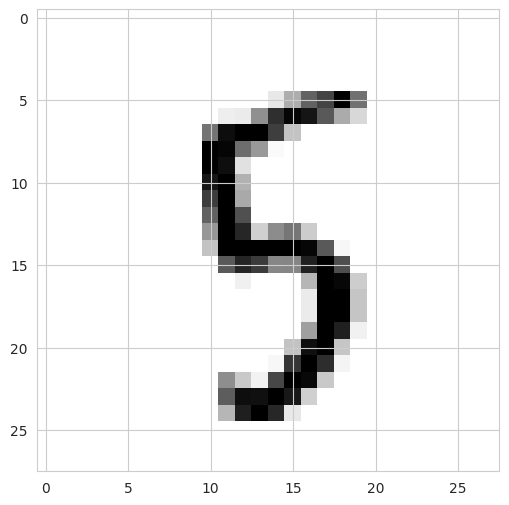

This digit is equal to 9: 0


In [20]:
random_idx = np.random.randint(0, 20)
random_digit = X_init[random_idx]
random_digit_img = random_digit.reshape(28, 28)

plt.imshow(random_digit_img, cmap=matplotlib.cm.binary, interpolation="nearest")
plt.axis("on")
plt.show()

print(f"This digit is equal to 9: {y_init[random_idx]}")  # If True, return 1, else 0

#### 2 Acquisition Functions
* Random (Uniform): baseline
* Max Predictive Entropy
* BALD (max Mutial Information)

In [21]:
def predictions_from_pool(
    model, X_pool: np.ndarray, T: int = 100, training: bool = True
):
    """Run random_subset prediction on model and return the output
    Attributes:
        X_pool: Pool set to select uncertainty,
        T: Number of MC dropout iterations aka training iterations,
        training: If False, run test without MC dropout. (default=True)
    """
    random_subset = np.random.choice(range(len(X_pool)), size=500, replace=False)
    with torch.no_grad():
        outputs = np.stack(
            [
                torch.softmax(
                    model.estimator.forward(X_pool[random_subset], training=training),
                    dim=-1,
                )
                .cpu()
                .numpy()
                for _ in range(T)
            ]
        )
    return outputs, random_subset


def uniform(
    model, X_pool: np.ndarray, n_query: int = 10, T: int = 100, training: bool = True
):
    """Baseline acquisition a(x) = unif() with unif() a function
    returning a draw from a uniform distribution over the interval [0,1].
    Using this acquisition function is equivalent to choosing a point
    uniformly at random from the pool.
    Attributes:
        X_pool: Pool set to select uncertainty,
        n_query: Number of points that randomly select from pool set,
        training: If False, run test without MC dropout. (default=True)
    """
    query_idx = np.random.choice(range(len(X_pool)), size=n_query, replace=False)
    return query_idx, X_pool[query_idx]


def shannon_entropy_function(
    model, X_pool: np.ndarray, T: int = 100, E_H: bool = False, training: bool = True
):
    """H[y|x,D_train] := - sum_{c} p(y=c|x,D_train)log p(y=c|x,D_train)
    Attributes:
        model: Model that is ready to measure uncertainty after training,
        X_pool: Pool set to select uncertainty,
        T: Number of MC dropout iterations aka training iterations,
        E_H: If True, compute H and EH for BALD (default: False),
        training: If False, run test without MC dropout. (default=True)
    """
    outputs, random_subset = predictions_from_pool(model, X_pool, T, training=training)
    pc = outputs.mean(axis=0)
    H = (-pc * np.log(pc + 1e-10)).sum(
        axis=-1
    )  # To avoid division with zero, add 1e-10
    if E_H:
        E = -np.mean(np.sum(outputs * np.log(outputs + 1e-10), axis=-1), axis=0)
        return H, E, random_subset
    return H, random_subset


def max_entropy(
    model, X_pool: np.ndarray, n_query: int = 10, T: int = 100, training: bool = True
):
    """Choose pool points that maximise the predictive entropy.
    Using Shannon entropy function.
    Attributes:
        model: Model that is ready to measure uncertainty after training,
        X_pool: Pool set to select uncertainty,
        n_query: Number of points that maximise max_entropy a(x) from pool set,
        T: Number of MC dropout iterations aka training iterations,
        training: If False, run test without MC dropout. (default=True)
    """
    acquisition, random_subset = shannon_entropy_function(
        model, X_pool, T, training=training
    )
    idx = (-acquisition).argsort()[:n_query]
    query_idx = random_subset[idx]
    return query_idx, X_pool[query_idx]


def bald(
    model, X_pool: np.ndarray, n_query: int = 10, T: int = 100, training: bool = True
):
    """Choose pool points that are expected to maximise the information
    gained about the model parameters, i.e. maximise the mutal information
    between predictions and model posterior. Given
    I[y,w|x,D_train] = H[y|x,D_train] - E_{p(w|D_train)}[H[y|x,w]]
    with w the model parameters (H[y|x,w] is the entropy of y given w).
    Points that maximise this acquisition function are points on which the
    model is uncertain on average but there exist model parameters that produce
    disagreeing predictions with high certainty. This is equivalent to points
    with high variance in th einput to the softmax layer
    Attributes:
        model: Model that is ready to measure uncertainty after training,
        X_pool: Pool set to select uncertainty,
        n_query: Number of points that maximise bald a(x) from pool set,
        T: Number of MC dropout iterations aka training iterations,
        training: If False, run test without MC dropout. (default=True)
    """
    H, E_H, random_subset = shannon_entropy_function(
        model, X_pool, T, E_H=True, training=training
    )
    acquisition = H - E_H
    idx = (-acquisition).argsort()[:n_query]
    query_idx = random_subset[idx]
    return query_idx, X_pool[query_idx]

#### 2.1 Define CNN architecture

In [22]:
class ConvNN(nn.Module):
    def __init__(
        self,
        num_filters: int = 32,
        kernel_size: int = 4,
        dense_layer: int = 128,
        img_rows: int = 28,
        img_cols: int = 28,
        maxpool: int = 2,
    ):
        """
        Basic Architecture of CNN
        Attributes:
            num_filters: Number of filters, out channel for 1st and 2nd conv layers,
            kernel_size: Kernel size of convolution,
            dense_layer: Dense layer units,
            img_rows: Height of input image,
            img_cols: Width of input image,
            maxpool: Max pooling size
        """
        super(ConvNN, self).__init__()
        self.conv1 = nn.Conv2d(1, num_filters, kernel_size, 1)
        self.conv2 = nn.Conv2d(num_filters, num_filters, kernel_size, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(
            num_filters
            * ((img_rows - 2 * kernel_size + 2) // 2)
            * ((img_cols - 2 * kernel_size + 2) // 2),
            dense_layer,
        )
        self.fc2 = nn.Linear(dense_layer, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        out = self.fc2(x)
        return out

#### 2.2 Define Active Learning Procedure

In [23]:
def active_learning_procedure(
    query_strategy,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    X_pool: np.ndarray,
    y_pool: np.ndarray,
    X_init: np.ndarray,
    y_init: np.ndarray,
    estimator,
    T: int = 100,
    n_query: int = 10,
    training: bool = True,
):
    """Active Learning Procedure
    Attributes:
        query_strategy: Choose between Uniform(baseline), max_entropy, bald,
        X_val, y_val: Validation dataset,
        X_test, y_test: Test dataset,
        X_pool, y_pool: Query pool set,
        X_init, y_init: Initial training set data points,
        estimator: Neural Network architecture, e.g. CNN,
        T: Number of MC dropout iterations (repeat acqusition process T times),
        n_query: Number of points to query from X_pool,
        training: If False, run test without MC Dropout (default: True)
    """
    learner = ActiveLearner(
        estimator=estimator,
        X_training=X_init,
        y_training=y_init,
        query_strategy=query_strategy,
    )
    perf_hist = [learner.score(X_test, y_test)]
    for index in range(T):
        query_idx, query_instance = learner.query(
            X_pool, n_query=n_query, T=T, training=training
        )
        learner.teach(X_pool[query_idx], y_pool[query_idx])
        X_pool = np.delete(X_pool, query_idx, axis=0)
        y_pool = np.delete(y_pool, query_idx, axis=0)
        model_accuracy_val = learner.score(X_val, y_val)
        if (index + 1) % 5 == 0:
            print(f"Val Accuracy after query {index+1}: {model_accuracy_val:0.4f}")
        perf_hist.append(model_accuracy_val)
    model_accuracy_test = learner.score(X_test, y_test)
    print(f"********** Test Accuracy per experiment: {model_accuracy_test} **********")
    return perf_hist, model_accuracy_test

#### 3.0 Define Hyperparameters

In [24]:
ACQ_FUNCS = [uniform, max_entropy, bald]
BATCH_SIZE = 128
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DROPOUT_ITER = 100
EPOCHS = 50
EXPERIMENTS = 3
N_QUERY = 1
LR = 1e-3
RESULT_DIR = "result_npy"
SEED = 369


if not os.path.exists(RESULT_DIR):
    os.mkdir(RESULT_DIR)


print(f"Using device: {DEVICE}")

Using device: cuda:0


#### 3.1 Functions

In [25]:
def load_CNN_model():
    """Load new model each time for different acqusition function
    each experiments"""
    model = ConvNN().to(DEVICE)
    cnn_classifier = NeuralNetClassifier(
        module=model,
        lr=LR,
        batch_size=BATCH_SIZE,
        max_epochs=EPOCHS,
        criterion=nn.CrossEntropyLoss,
        optimizer=torch.optim.Adam,
        train_split=None,
        verbose=0,
        device=DEVICE,
    )
    return cnn_classifier


def save_as_npy(data: np.ndarray, name: str):
    """Save result as npy file

    Attributes:
        data: np array to be saved as npy file,
        folder: result folder name,
        name: npy filename
    """
    file_name = os.path.join(RESULT_DIR, name + ".npy")
    np.save(file_name, data)
    print(f"Saved: {file_name}")


def plot_results(data: dict, ylim=[0.94, 1.00]):
    """Plot results histogram using matplotlib"""
    sns.set()
    plt.figure(figsize=(7, 5))
    for key in data.keys():
        data[key] = gaussian_filter1d(data[key], sigma=0.9)  # for smoother graph
        plt.plot(data[key], label=key)
    plt.ylim(ylim)
    plt.legend()
    plt.show()


def print_elapsed_time(start_time: float, exp: int, acq_func: str):
    """Print elapsed time for each experiment of acquiring
    Attributes:
        start_time: Starting time (in time.time()),
        exp: Experiment iteration
        acq_func: Name of acquisition function
    """
    elp = time.time() - start_time
    print(
        f"********** Experiment {exp} ({acq_func}): {int(elp//3600)}:\
        {int(elp%3600//60)}:{int(elp%60)} **********"
    )

#### 4.0 Start Active Learning with Acquisition Functions
- random
- max_entropy
- bald

In [26]:
results = dict()


for i, acq_func in enumerate(ACQ_FUNCS):
    avg_hist = []
    test_scores = []
    acq_func_name = str(acq_func).split(" ")[1]
    print(f"\n---------- Start {acq_func_name} training! ----------")
    for e in range(EXPERIMENTS):
        start_time = time.time()
        estimator = load_CNN_model()
        print(f"********** Experiment Iterations: {e+1}/{EXPERIMENTS} **********")
        training_hist, test_score = active_learning_procedure(
            query_strategy=acq_func,
            X_val=X_val,
            y_val=y_val,
            X_test=X_test,
            y_test=y_test,
            X_pool=X_pool,
            y_pool=y_pool,
            X_init=X_init,
            y_init=y_init,
            estimator=estimator,
            T=DROPOUT_ITER,
            n_query=N_QUERY,
        )
        avg_hist.append(training_hist)
        test_scores.append(test_score)
        print_elapsed_time(start_time, e + 1, acq_func_name)
    avg_hist = np.average(np.array(avg_hist), axis=0)
    avg_test = sum(test_scores) / len(test_scores)
    print(f"Average Test score for {acq_func_name}: {avg_test}")
    results[acq_func_name] = avg_hist
    save_as_npy(data=avg_hist, name=acq_func_name)


print("--------------- Done Training! ---------------")


---------- Start uniform training! ----------
********** Experiment Iterations: 1/3 **********
Val Accuracy after query 5: 0.6567
Val Accuracy after query 10: 0.7567
Val Accuracy after query 15: 0.7167
Val Accuracy after query 20: 0.8000
Val Accuracy after query 25: 0.7767
Val Accuracy after query 30: 0.8233
Val Accuracy after query 35: 0.8733
Val Accuracy after query 40: 0.8833
Val Accuracy after query 45: 0.8867
Val Accuracy after query 50: 0.8867
Val Accuracy after query 55: 0.9067
Val Accuracy after query 60: 0.9100
Val Accuracy after query 65: 0.8933
Val Accuracy after query 70: 0.9233
Val Accuracy after query 75: 0.9467
Val Accuracy after query 80: 0.9133
Val Accuracy after query 85: 0.9400
Val Accuracy after query 90: 0.9533
Val Accuracy after query 95: 0.9467
Val Accuracy after query 100: 0.9400
********** Test Accuracy per experiment: 0.9359 **********
********** Experiment 1 (uniform): 0:        0:34 **********
********** Experiment Iterations: 2/3 **********
Val Accuracy af

#### 4.1 Plot Deep Bayesian Active Learning Results

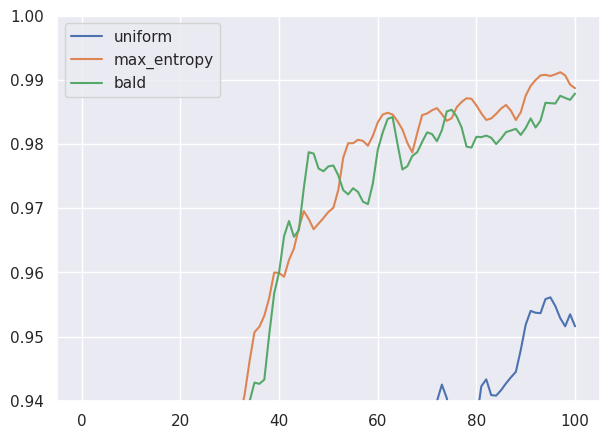

In [27]:
plot_results(data=results)

In [28]:
uniform = np.load("result_npy/uniform.npy")
bald = np.load("result_npy/bald.npy")
max_entropy = np.load("result_npy/max_entropy.npy")

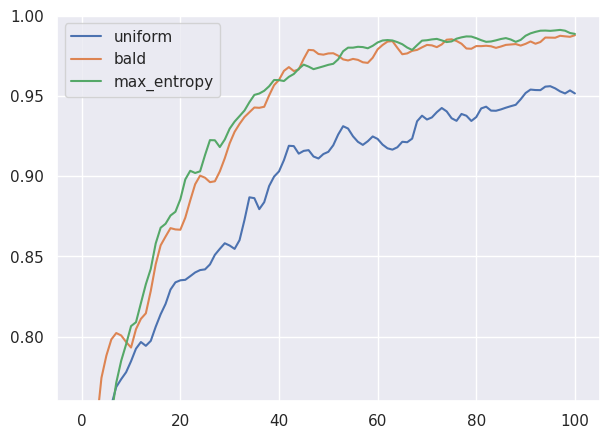

In [29]:
plot_results(
    {
        "uniform": uniform,
        "bald": bald,
        "max_entropy": max_entropy,
    },
    ylim=[0.76, 1],
)

**Task 3.1 (20 min):**
Why do you think BALD is inferior to Max Entropy?  
Try to fix BALD.

In [ ]:
# your code here